# 01 — Exploration des Données (EDA)
**Thèse DIA — Validation externe DG Cameroun**

Objectif : explorer les 3 datasets bruts SANS les modifier, pour documenter
leur état initial (base de comparaison avant nettoyage).

⚠️ Ce notebook ne modifie AUCUN fichier — lecture seule sur `data/raw/`.


In [2]:
import sys
sys.path.append('../src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from visualization import plot_missing_data_heatmap, PALETTE

pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid')
%matplotlib inline


## 1.1 Chargement des 3 datasets bruts

In [3]:
df_france = pd.read_csv('../data/raw/dataset_dg_france_30000_final.csv')
df_positifs = pd.read_csv('../data/raw/Cas_positifs_243.csv')
df_negatifs = pd.read_csv('../data/raw/cas_negatifs_212.csv')

print(f"France (synthétique)   : {df_france.shape}")
print(f"Cameroun Positifs      : {df_positifs.shape}")
print(f"Cameroun Négatifs      : {df_negatifs.shape}")


France (synthétique)   : (30000, 30)
Cameroun Positifs      : (243, 36)
Cameroun Négatifs      : (212, 19)


## 1.2 Aperçu structure — France (dataset d'entraînement)

In [4]:
df_france.info()
df_france.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 30 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   patient_id                     30000 non-null  int64  
 1   annee_inclusion                30000 non-null  int64  
 2   centre_id                      30000 non-null  object 
 3   pays                           30000 non-null  object 
 4   age_maternel                   30000 non-null  float64
 5   parite                         30000 non-null  object 
 6   atcd_familial_diabete_1er_deg  26424 non-null  object 
 7   niveau_etude                   24634 non-null  object 
 8   zone_residence                 28461 non-null  object 
 9   taille_cm                      29108 non-null  float64
 10  poids_kg                       27900 non-null  float64
 11  imc                            30000 non-null  float64
 12  ta_systolique                  28833 non-null 

,patient_id,annee_inclusion,centre_id,pays,age_maternel,parite,atcd_familial_diabete_1er_deg,niveau_etude,zone_residence,taille_cm,poids_kg,imc,ta_systolique,ta_diastolique,sedentarite,tabagisme,alcoolisme,glycemie_jeun_1T,atcd_gdm,atcd_macrosomie,hta_chronique,atcd_preeclampsie,sopk,grossesse_multiple,sa_premiere_consult,ogtt_0min,ogtt_60min,ogtt_120min,critere_dg,gdm_label
0,1,2020,CHU_FR_01,France,31.871227,Multipare_3,Non,Supérieur,Urbain,157.658941,54.713513,22.011893,112.658290,68.380494,Oui,NaN,Non,0.759829,NaN,Non,Non,Non,Non,Non,11.666148,NaN,NaN,NaN,IADPSG_2013,Non
1,2,2020,CHU_FR_01,France,25.820072,Primipare,Non,NaN,Urbain,164.899343,68.392765,25.151988,125.436519,74.027550,Oui,Non,Non,0.808598,Non,Non,Non,Non,Non,Non,12.716590,NaN,NaN,NaN,IADPSG_2013,Non
2,3,2020,CHU_FR_01,France,33.877030,Primipare,Non,Primaire,Urbain,161.890031,NaN,29.276214,114.620089,67.757101,NaN,Non,Non,NaN,Non,NaN,Non,Non,Non,Non,6.013297,NaN,NaN,NaN,IADPSG_2013,Non
3,4,2020,CHU_FR_01,France,34.732541,Nullipare,Oui,Supérieur,Urbain,162.573094,73.628445,27.857894,117.695387,69.040675,NaN,NaN,Non,NaN,Non,Non,NaN,Non,Non,Non,6.088479,NaN,NaN,NaN,IADPSG_2013,Non
4,5,2020,CHU_FR_01,France,21.720342,Nullipare,Non,Aucun,Urbain,163.804228,71.193818,26.533349,108.848857,65.750691,Oui,Non,Non,0.806900,Non,Non,Oui,NaN,Non,Non,10.414157,NaN,NaN,NaN,IADPSG_2013,Non


gdm_label
Non    26623
Oui     3377
Name: count, dtype: int64

Taux de positifs : 11.3%


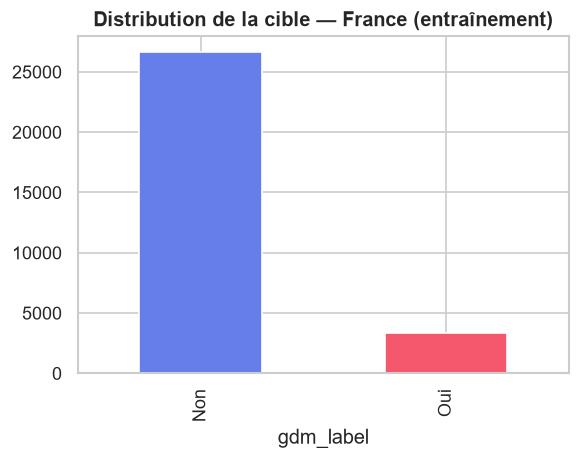

In [5]:
# Distribution de la target
print(df_france['gdm_label'].value_counts())
print(f"\nTaux de positifs : {(df_france['gdm_label']=='Oui').mean()*100:.1f}%")

fig, ax = plt.subplots(figsize=(5,4))
df_france['gdm_label'].value_counts().plot(kind='bar', color=[PALETTE['primary'], PALETTE['warning']], ax=ax)
ax.set_title('Distribution de la cible — France (entraînement)', fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/01_distribution_target_france.png', dpi=120)
plt.show()


## 1.3 Valeurs manquantes — France

In [6]:
missing = df_france.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df_france) * 100).round(2)
missing_summary = pd.DataFrame({'n_manquant': missing, 'pct_manquant': missing_pct})
missing_summary = missing_summary[missing_summary['n_manquant'] > 0]
print(missing_summary)


                               n_manquant  pct_manquant
ogtt_120min                         19535         65.12
ogtt_60min                          19535         65.12
ogtt_0min                           19535         65.12
glycemie_jeun_1T                    10358         34.53
sedentarite                          6593         21.98
alcoolisme                           5922         19.74
niveau_etude                         5366         17.89
sopk                                 4490         14.97
atcd_familial_diabete_1er_deg        3576         11.92
tabagisme                            3046         10.15
atcd_macrosomie                      2964          9.88
atcd_preeclampsie                    2956          9.85
atcd_gdm                             2371          7.90
poids_kg                             2100          7.00
zone_residence                       1539          5.13
ta_diastolique                       1207          4.02
ta_systolique                        1167       

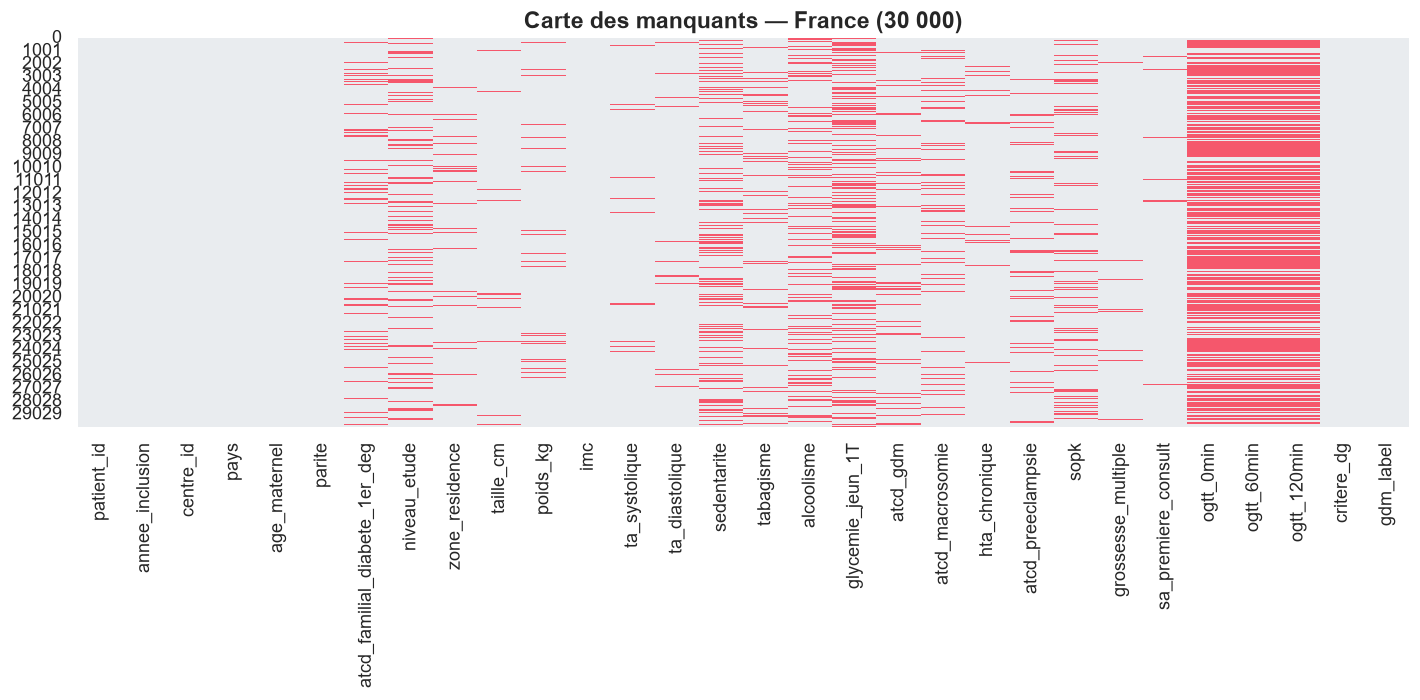

In [7]:
fig = plot_missing_data_heatmap(df_france, title='Carte des manquants — France (30 000)',
                                  save_path='../figures/01_missing_heatmap_france.png')
plt.show()


## 1.4 Aperçu structure — Cameroun Positifs (243)\n\n⚠️ Dataset chaotique attendu : IMC catégoriel, tension combinée, formats texte.

In [8]:
df_positifs.info()
df_positifs.head(3)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 36 columns):
 #   Column                                                              Non-Null Count  Dtype  
---  ------                                                              --------------  -----  
 0   Horodateur                                                          243 non-null    object 
 1   Numéro de  code                                                     19 non-null     object 
 2   Date d'inclusion                                                    6 non-null      object 
 3   Age (en années)                                                     243 non-null    object 
 4   Lieu de résidence                                                   27 non-null     object 
 5   Profession                                                          239 non-null    object 
 6   Niveau d'instruction                                                242 non-null    object 
 7   Statut matrimonia

,Horodateur,Numéro de code,Date d'inclusion,Age (en années),Lieu de résidence,Profession,Niveau d'instruction,Statut matrimonial,Couverture santé,ATCD de diabète gestationnel,ATCD familiaux de diabète (1er degré),ATCD de macrosomie (>4kg),Antécédent de SOPK (kystes ovariens),ATCD d’HTA(Hypertension artérielle) ou pré-éclampsie,Nombre de grossesses (gravida),Nombre d’accouchements (parité),Tabagisme(actif/passif),Contraception hormonale avant grossesse,Sédentaire?(moins de 150 minutes d'activité physique par semaine).,Âge gestationnel (en SA) à l’inclusion,Poids actuel (kg),Taille (cm),IMC( kg/m²),Pression arterielle(mm Hg),Glycémie à jeun (si dispo),Hémoglobine glyquée (si dispo),OGTT prévue à 24-28 SA ?,OGTT effectué,Résultat OGTT (À jeun ),Résultat OGTT ( 1h),Résultat OGTT ( 2h),Diagnostic DG,Prise de poids pendant la grossesse(Kg),Issue de la grossesse,Colonne 34,Colonne 32
0,23/03/2026 18:44:00,001,NaN,37,NaN,commercante,Secondaire,Marié,Non,oui,Oui,Oui,Non,Non,3.0,2,Non,Non,Non,11SA,85.0,167,30.5,120-139/90,"0,95",NaN,Oui,NaN,NaN,NaN,NaN,Oui,NaN,NaN,NaN,NaN
1,23/03/2026 18:57:31,002,NaN,35,NaN,cadre,Superieur,Marié,Non,Non,Non,Oui,Non,Non,6.0,5,Non,Non,Non,14SA,76.0,165,"25-29,9",90-120/60-90,"0,94",NaN,Oui,NaN,NaN,NaN,NaN,Oui,NaN,NaN,NaN,NaN
2,23/03/2026 19:00:58,003,NaN,22,NaN,etudiante,Superieur,Célibataire,Non,Non,Oui,Oui,Non,Non,2.0,1,Non,Oui,NaN,9SA,NaN,NaN,"25-29,9",90-120/60-90,"0,93",NaN,NaN,NaN,NaN,NaN,NaN,Oui,NaN,NaN,NaN,NaN


In [9]:
missing_pos = df_positifs.isnull().sum().sort_values(ascending=False)
missing_pos_pct = (missing_pos / len(df_positifs) * 100).round(1)
print(pd.DataFrame({'n_manquant': missing_pos, 'pct': missing_pos_pct})[missing_pos > 0])


                                                    n_manquant    pct
Colonne 32                                                 243  100.0
Colonne 34                                                 242   99.6
Hémoglobine glyquée (si dispo)                             242   99.6
Prise de poids pendant la grossesse(Kg)                    241   99.2
Date d'inclusion                                           237   97.5
Taille (cm)                                                235   96.7
Poids actuel (kg)                                          235   96.7
Numéro de  code                                            224   92.2
Lieu de résidence                                          216   88.9
Résultat OGTT ( 1h)                                        200   82.3
Résultat OGTT ( 2h)                                        194   79.8
Résultat OGTT (À jeun )                                    158   65.0
OGTT effectué                                              130   53.5
Issue de la grossess

## 1.5 Aperçu structure — Cameroun Négatifs (212)\n\n⚠️ Attention : pas de NaN mais valeurs 'Non_renseigne' à traiter.

In [10]:
df_negatifs.info()
df_negatifs.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 212 entries, 0 to 211
Data columns (total 19 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age_maternel                   212 non-null    float64
 1   parite                         212 non-null    object 
 2   niveau_etude                   212 non-null    object 
 3   zone_residence                 212 non-null    object 
 4   imc                            212 non-null    float64
 5   ta_systolique                  212 non-null    float64
 6   ta_diastolique                 212 non-null    float64
 7   hta_chronique                  212 non-null    object 
 8   sedentarite                    212 non-null    object 
 9   tabagisme                      212 non-null    object 
 10  alcoolisme                     212 non-null    object 
 11  atcd_gdm                       212 non-null    object 
 12  atcd_macrosomie                212 non-null    obj

,age_maternel,parite,niveau_etude,zone_residence,imc,ta_systolique,ta_diastolique,hta_chronique,sedentarite,tabagisme,alcoolisme,atcd_gdm,atcd_macrosomie,atcd_preeclampsie,atcd_familial_diabete_1er_deg,sopk,grossesse_multiple,sa_premiere_consult,gdm_label
0,34.0,Primipare,Secondaire,Urbain,31.97,107.0,64.0,Non_renseigne,Non_renseigne,Non_renseigne,Non_renseigne,Non,Non,Non_renseigne,Non,Non_renseigne,Non_renseigne,11.142857,Non
1,21.0,Nullipare,Secondaire,Urbain,25.60,108.0,60.0,Non_renseigne,Non_renseigne,Non_renseigne,Non_renseigne,Non,Non,Non_renseigne,Non,Non_renseigne,Non_renseigne,13.571429,Non
2,41.0,Multipare_2,Secondaire,Urbain,26.57,103.0,71.0,Non_renseigne,Non_renseigne,Non_renseigne,Non_renseigne,Non,Oui,Non_renseigne,Non,Non_renseigne,Non_renseigne,13.428571,Non
3,29.0,Multipare_3,Secondaire,Urbain,28.90,114.0,77.0,Non_renseigne,Non_renseigne,Non_renseigne,Non_renseigne,Non,Non,Non_renseigne,Non,Non_renseigne,Non_renseigne,13.714286,Non
4,25.0,Multipare_2,Secondaire,Urbain,36.10,102.0,61.0,Non_renseigne,Non_renseigne,Non_renseigne,Non_renseigne,Non,Oui,Non_renseigne,Oui,Non_renseigne,Non_renseigne,13.714286,Non


In [11]:
# Recherche des 'Non_renseigne'
for col in df_negatifs.columns:
    n_nr = (df_negatifs[col] == 'Non_renseigne').sum()
    if n_nr > 0:
        print(f"{col}: {n_nr} ({n_nr/len(df_negatifs)*100:.1f}%) 'Non_renseigne'")


parite: 2 (0.9%) 'Non_renseigne'
zone_residence: 103 (48.6%) 'Non_renseigne'
hta_chronique: 108 (50.9%) 'Non_renseigne'
sedentarite: 108 (50.9%) 'Non_renseigne'
tabagisme: 108 (50.9%) 'Non_renseigne'
alcoolisme: 212 (100.0%) 'Non_renseigne'
atcd_preeclampsie: 108 (50.9%) 'Non_renseigne'
sopk: 108 (50.9%) 'Non_renseigne'
grossesse_multiple: 212 (100.0%) 'Non_renseigne'


## 1.6 🚨 Découverte critique — Pattern structurel des manquants (Négatifs)

Vérification : les "Non_renseigne" sont-ils répartis aléatoirement ou concentrés
sur les mêmes femmes (signature de 2 sous-cohortes fusionnées) ?


In [12]:
vars_check = ['sopk','sedentarite','tabagisme','hta_chronique','atcd_preeclampsie']
mask = pd.DataFrame({v: df_negatifs[v]=='Non_renseigne' for v in vars_check})
n_manquants_par_femme = mask.sum(axis=1)
print("Nombre de variables 'Non_renseigne' simultanément, par femme :")
print(n_manquants_par_femme.value_counts().sort_index())
print("\n-> Si distribution bimodale (0 ou 5, jamais 1-4) : confirme 2 sous-cohortes distinctes")

# Vérifier contiguïté des lignes concernées
idx_block = df_negatifs[n_manquants_par_femme == 5].index.tolist()
print(f"\nLignes concernées : {idx_block[0]} à {idx_block[-1]} ({len(idx_block)} lignes)")
print(f"Contiguës ? {(pd.Series(idx_block).diff().dropna() == 1).all()}")


Nombre de variables 'Non_renseigne' simultanément, par femme :
0    104
5    108
Name: count, dtype: int64

-> Si distribution bimodale (0 ou 5, jamais 1-4) : confirme 2 sous-cohortes distinctes

Lignes concernées : 0 à 107 (108 lignes)
Contiguës ? True


**Interprétation :** Ce bloc de 108 lignes contiguës avec exactement les 5 mêmes variables
manquantes constitue une preuve quasi certaine de deux sources de collecte fusionnées.
Documenté dans la thèse comme finding méthodologique. Traité au notebook 06 (test `flag_source_batch`).

## 1.7 Comparaison distributionnelle France vs Cameroun (variables communes numériques)

C:\Users\darry\AppData\Local\Temp\ipykernel_16672\2899953564.py:20: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.tight_layout()
c:\PROJECTS\GDM_VALIDATION_PROJECT\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


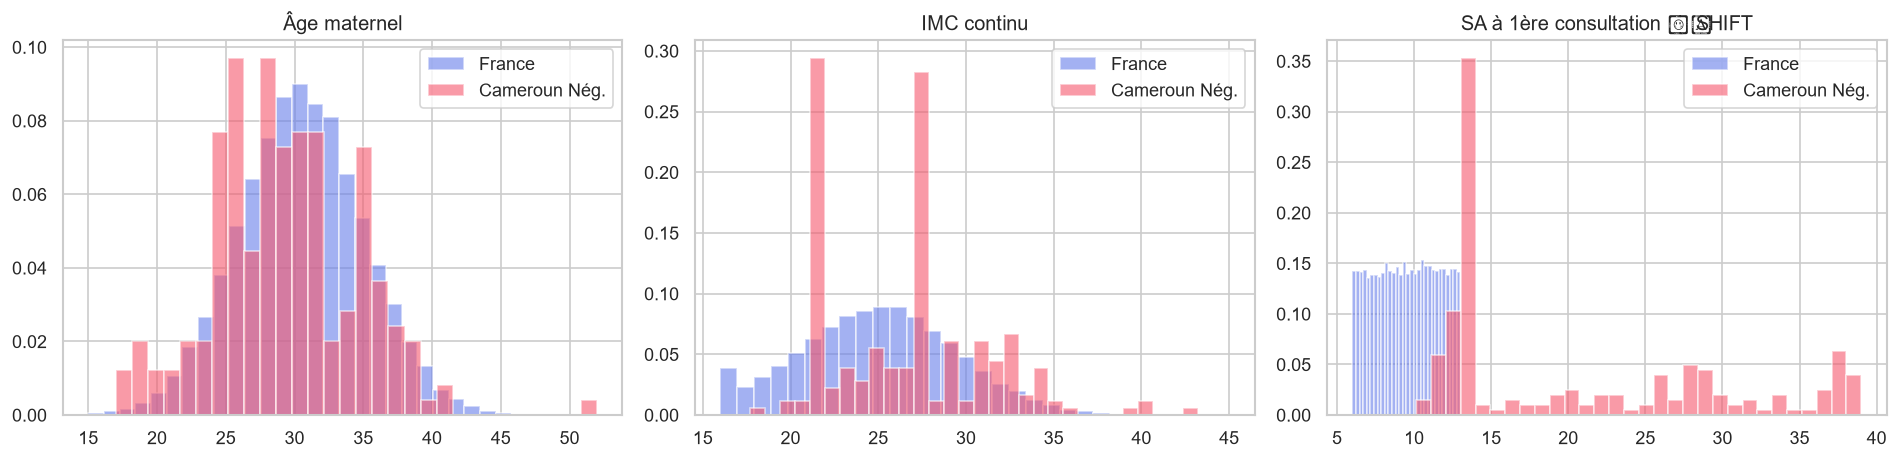

SA 1ère consult — France: 9.5 SA
SA 1ère consult — Cameroun Nég.: 20.7 SA
>> Les Camerounaises consultent en moyenne 2x plus tard. Shift distributionnel majeur à documenter.


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16,4))

# Age
axes[0].hist(df_france['age_maternel'].dropna(), bins=30, alpha=0.6, label='France', color=PALETTE['primary'], density=True)
axes[0].hist(df_negatifs['age_maternel'].dropna(), bins=30, alpha=0.6, label='Cameroun Nég.', color=PALETTE['warning'], density=True)
axes[0].set_title('Âge maternel'); axes[0].legend()

# IMC
axes[1].hist(df_france['imc'].dropna(), bins=30, alpha=0.6, label='France', color=PALETTE['primary'], density=True)
axes[1].hist(df_negatifs['imc'].dropna(), bins=30, alpha=0.6, label='Cameroun Nég.', color=PALETTE['warning'], density=True)
axes[1].set_title('IMC continu')
axes[1].legend()

# SA première consultation — SHIFT MAJEUR ATTENDU
axes[2].hist(df_france['sa_premiere_consult'].dropna(), bins=30, alpha=0.6, label='France', color=PALETTE['primary'], density=True)
axes[2].hist(df_negatifs['sa_premiere_consult'].dropna(), bins=30, alpha=0.6, label='Cameroun Nég.', color=PALETTE['warning'], density=True)
axes[2].set_title('SA à 1ère consultation ⚠️ SHIFT')
axes[2].legend()

plt.tight_layout()
plt.savefig('../figures/01_comparaison_distributions.png', dpi=120)
plt.show()

print(f"SA 1ère consult — France: {df_france['sa_premiere_consult'].mean():.1f} SA")
print(f"SA 1ère consult — Cameroun Nég.: {df_negatifs['sa_premiere_consult'].mean():.1f} SA")
print(">> Les Camerounaises consultent en moyenne 2x plus tard. Shift distributionnel majeur à documenter.")


## 1.8 Synthèse EDA

**Points clés à retenir pour le notebook 02 (nettoyage) :**
1. France : manquants modérés (2-65% selon variable), cohérents, imputables
2. Positifs : IMC et tension en catégories texte -> binning ordinal requis
3. Négatifs : "Non_renseigne" à convertir en NaN ; structure à 2 sous-cohortes détectée
4. Shift distributionnel confirmé sur SA 1ère consultation (9.5 vs 20.7 SA)
5. Variables à exclure d'office : glycemie_jeun_1T, taille_cm, poids_kg, alcoolisme,
   grossesse_multiple, zone_residence (trop de manquants ou absentes côté Cameroun)

➡️ **Suite : notebook 02_data_cleaning.ipynb**
